Objective: An onlike book store wants to promote its sales by easily recommending books for customers best on their historical preferences

In [ ]:
pip install pandas numpy seaborn matplotlib scikit-learn

importing data from google drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
file_path= '/content/drive/My Drive/Data Science Projects/Book Recomender/Books.csv'
books_df = pd.read_csv(file_path)
books_df.head()


/tmp/ipykernel_1101/3361812884.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books_df = pd.read_csv(file_path)


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [5]:
file_path= '/content/drive/My Drive/Data Science Projects/Book Recomender/Ratings.csv'
rating_df = pd.read_csv(file_path)
rating_df.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [6]:
file_path= '/content/drive/My Drive/Data Science Projects/Book Recomender/Users.csv'
users_df = pd.read_csv(file_path)
users_df.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


### Merging DataFrames


In [7]:
merged_df = pd.merge(rating_df, books_df, on='ISBN', how='left')
joined_data = pd.merge(merged_df, users_df, on='User-ID', how='left')

print("Shape of the joined data:", joined_data.shape)
display(joined_data.head())

Shape of the joined data: (1149780, 12)


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa",NaN
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa",NaN
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,"h, new south wales, australia",16.0
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,"rijeka, n/a, croatia",16.0
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,"rijeka, n/a, croatia",16.0


Data cleaning and exploration

### Handling Duplicates


In [8]:

joined_data.drop_duplicates(subset=['User-ID', 'ISBN'], inplace=True)
print("Shape after dropping duplicates:", joined_data.shape)
display(joined_data.head())

Shape after dropping duplicates: (1149780, 12)


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa",NaN
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa",NaN
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,"h, new south wales, australia",16.0
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,"rijeka, n/a, croatia",16.0
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,"rijeka, n/a, croatia",16.0


### Handling Missing Values


In [ ]:
numeric_cols = joined_data.select_dtypes(include=['number']).columns
for col in numeric_cols:
    if joined_data[col].isnull().any():
        median_val = joined_data[col].median()
        joined_data[col].fillna(median_val, inplace=True)
        print(f"Filled NaN in column '{col}' with median: {median_val}")

print("\nInformation about the cleaned data:")
joined_data.info()
print("\nNumber of null values after cleaning:")
display(joined_data.isnull().sum())

In [10]:

total_count = len(joined_data)
null_counts = joined_data.isnull().sum()
percentage_null = (null_counts / total_count) * 100

print(percentage_null)


User-ID                 0.000000
ISBN                    0.000000
Book-Rating             0.000000
Book-Title             10.318844
Book-Author            10.319018
Year-Of-Publication    10.318844
Publisher              10.319018
Image-URL-S            10.318844
Image-URL-M            10.318844
Image-URL-L            10.319191
Location                0.000000
Age                     0.000000
dtype: float64


Since percentage null is approximately 10% I will drop null values

In [11]:
joined_data= joined_data.dropna()

Confirming if null values have been eradicated

In [12]:

total_count = len(joined_data)
null_counts = joined_data.isnull().sum()
percentage_null = (null_counts / total_count) * 100

print(percentage_null)

User-ID                0.0
ISBN                   0.0
Book-Rating            0.0
Book-Title             0.0
Book-Author            0.0
Year-Of-Publication    0.0
Publisher              0.0
Image-URL-S            0.0
Image-URL-M            0.0
Image-URL-L            0.0
Location               0.0
Age                    0.0
dtype: float64


Cleaning and changing data types in joined data


In [13]:

joined_data['ISBN'] = joined_data['ISBN'].astype(str).str.replace(r'[/^a-zA-Z/]', '', regex=True)



In [ ]:
joined_data['ISBN'].dtype

dtype('O')

In [14]:
joined_data['Book-Title'] = joined_data['Book-Title'].astype(str)
joined_data['Book-Author'] = joined_data['Book-Author'].astype(str)
joined_data['Publisher'] = joined_data['Publisher'].astype(str)
joined_data['Image-URL-L'] = joined_data['Image-URL-L'].astype(str)
joined_data['Image-URL-M'] = joined_data['Image-URL-M'].astype(str)
joined_data['Image-URL-S'] = joined_data['Image-URL-S'].astype(str)

converting year to date

In [15]:
joined_data['Year-Of-Publication'] = pd.to_datetime(joined_data['Year-Of-Publication'], errors='coerce')


Unsupervised learning

NMF

In [32]:
numerical_features = joined_data[['Book-Rating', 'Age']]

In [17]:
def recommend_similar_books (book_title, norm_features, joined_data, top_n=5):
  temp_book_title_features = pd.DataFrame(norm_features, index=joined_data['Book-Title'])
  temp_book_title_features.index.name = 'Book-Title'
  booktitle_nmf_features = temp_book_title_features.groupby('Book-Title').mean()
  if book_title in booktitle_nmf_features.index:
    book = booktitle_nmf_features.loc[book_title]
  else:
    print("Book ttle not found, search for another boook")

  similarities = booktitle_nmf_features.dot(book)

  return similarities.nlargest(top_n)

In [19]:
similar_books= recommend_similar_books("The Notebook", norm_features, joined_data, top_n=5)
print(similar_books)

Book-Title
Bedtime Hugs for Little Ones                                                                     0.579279
Mathematik fÃ?Â¼r Wirtschaftswissenschaftler, Elementare Grundlagen fÃ?Â¼r StudienanfÃ?Â¤nger    0.569292
Madrid, Distrito Federal (Biblioteca breve)                                                      0.559476
Boys' Toys: Bikes (Boys' Toys)                                                                   0.556666
Beauty of Sharing                                                                                0.546967
dtype: float64


In [55]:
similar_books= recommend_similar_books("Rites of Passage", norm_features, joined_data, top_n=5)
print(similar_books)

Book-Title
Another Field Guide to Little Known and Seldom Seen Birds of North America    0.897101
Les pensÃ?Â©es de San-Antonio                                                 0.897048
Stein und FlÃ?Â¶te und das ist noch nicht alles. Sonderausgabe.               0.897048
Ugly Duckling Sticker Storybook (Dover Little Activity Books)                 0.896938
Buddha Da                                                                     0.896782
dtype: float64


In [28]:
def get_authors (book_author, norm_features, joined_data, top_n=5):
  temp_author_book = pd.DataFrame(norm_features, index=joined_data['Book-Author'])
  temp_author_book.index.name = 'Book-Author'
  author_book_features = temp_author_book.groupby('Book-Author').mean()
  if book_author in author_book_features.index:
    book = author_book_features.loc[book_author]
    similarities = author_book_features.dot(book)
    return similarities.nlargest(top_n)
  else:
    print("Book author not found, search for another author")
    return None

In [23]:
joined_data['Book-Author'].unique()

array(['M. J. Rose', 'Judith Rae', 'Nicholas Sparks', ..., 'Kitta Reeds',
       'Kurt Messick', 'Joseph Delissio'], dtype=object)

In [29]:
get_authors("Judith Rae", norm_features, joined_data, top_n=5)

,0
Book-Author,
Debby Boone,0.638999
Jochen Schwarze,0.602291
Franz Beckenbauer,0.598997
Hulton Getty,0.591882
Janice A. Radway,0.584004


In [31]:
get_authors("Nicholas Sparks", norm_features, joined_data, top_n=5)

,0
Book-Author,
Debby Boone,0.569289
Jochen Schwarze,0.556199
Hulton Getty,0.546559
Charles E. Curran,0.533548
Franz Beckenbauer,0.525400


KMN

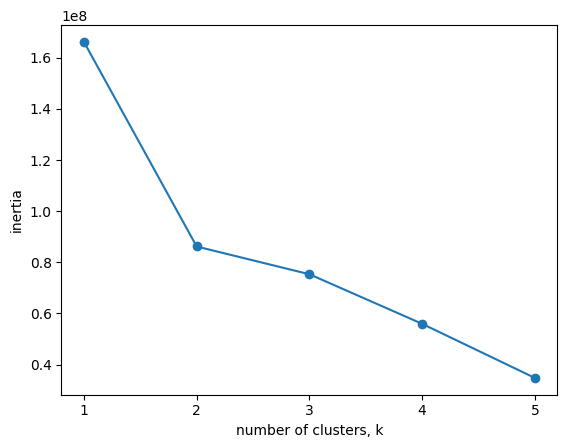

In [52]:
ks = range(1, 6)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters: model
    model= KMeans(n_clusters=k)

    # Fit model to samples
    model.fit(numerical_features)

    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)

# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()


In [50]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MaxAbsScaler

def get_similar_books_kmeans(book_title, features_df, joined_data, n_clusters=3, top_n=5):
    # 1. Create a DataFrame with book features, indexed by Book-Title
    # `features_df` is `numerical_features` which is already aligned with `joined_data` by its original index.
    temp_book_features_with_duplicates = pd.DataFrame(features_df.values, index=joined_data['Book-Title'])
    temp_book_features_with_duplicates.index.name = 'Book-Title'

    # Clean the index (book titles) for consistent grouping and lookup
    temp_book_features_with_duplicates.index = temp_book_features_with_duplicates.index.str.strip().str.lower()
    cleaned_book_title = book_title.strip().lower() # Clean the input book_title as well

    # 2. Group by Book-Title and take the mean of numerical features to get unique book features.
    unique_book_features = temp_book_features_with_duplicates.groupby(level='Book-Title').mean()

    # 3. Drop any remaining NaNs (if grouping introduced any or if they were already there and not handled by mean)
    unique_book_features_cleaned = unique_book_features.dropna()

    # 4. Scale the features before clustering
    scaler = MaxAbsScaler()
    scaled_features = scaler.fit_transform(unique_book_features_cleaned)

    # 5. Instantiate and fit KMeans model
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    clusters = kmeans.fit_predict(scaled_features)

    # 6. Add the 'Cluster' column to the DataFrame of unique book features
    unique_book_features_cleaned['Cluster'] = clusters

    # 7. Check if the target book exists in the cleaned, unique dataset
    if cleaned_book_title in unique_book_features_cleaned.index:
        # Find the cluster of the target book (will now be a scalar)
        target_cluster = unique_book_features_cleaned.loc[cleaned_book_title, 'Cluster']

        # Get other books in the same cluster
        cluster_books = unique_book_features_cleaned[unique_book_features_cleaned['Cluster'] == target_cluster].drop(cleaned_book_title, errors='ignore').copy()

        # Optionally rank by distance to centroid
        features_for_distance = cluster_books.drop(columns=['Cluster'])
        scaled_features_for_distance = scaler.transform(features_for_distance)

        distances = pd.Series(
            ((scaled_features_for_distance - kmeans.cluster_centers_[target_cluster])**2).sum(axis=1),
            index=cluster_books.index
        )
        return distances.nsmallest(top_n)
    else:
        print(f"'{book_title}' (cleaned to '{cleaned_book_title}') not found in dataset.")
        return None

In [53]:
get_similar_books_kmeans("The Notebook", numerical_features, joined_data, n_clusters=3, top_n=5)

,0
Book-Title,
balzac and the little chinese seamstress : a novel,2.069939e-07
a regency christmas: five new holiday tales (signet regency romance),6.222046e-07
"best man (those marrying mcbrides!) (intimate moments, 1010)",6.222046e-07
"defender (american hero) (silhouette intimate moments, no 589)",6.222046e-07
ein hinreissender schrotthã¤ndler: roman (roman dumont),6.222046e-07


In [47]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import MaxAbsScaler

# Prepare author-level features by grouping numerical features by author
author_features_df = joined_data.groupby('Book-Author')[['Book-Rating', 'Age']].mean()
print("Shape of author_features_df:", author_features_df.shape)
display(author_features_df.head())

def get_similar_authors_kmeans(target_author, features_df_authors, n_clusters=3, top_n=5):
    # Ensure no NaNs in the author features
    features_df_authors_cleaned = features_df_authors.dropna()

    # Scale the features before clustering
    scaler = MaxAbsScaler()
    scaled_features = scaler.fit_transform(features_df_authors_cleaned)

    # Instantiate and fit KMeans model
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    clusters = kmeans.fit_predict(scaled_features)

    # Add the 'Cluster' column to the cleaned author_features DataFrame
    features_df_authors_cleaned['Cluster'] = clusters

    # Check if target_author exists in the cleaned dataset
    if target_author in features_df_authors_cleaned.index:
        # Find cluster of the target author
        target_cluster = features_df_authors_cleaned.loc[target_author, 'Cluster']

        # Get other authors in the same cluster
        cluster_authors = features_df_authors_cleaned[features_df_authors_cleaned['Cluster'] == target_cluster].drop(target_author, errors='ignore').copy()

        # Rank by distance to centroid (optional, but good for fine-grained similarity within a cluster)
        scaled_cluster_authors_features = scaler.transform(cluster_authors.drop(columns=['Cluster']))

        distances = pd.Series(
            ((scaled_cluster_authors_features - kmeans.cluster_centers_[target_cluster])**2).sum(axis=1),
            index=cluster_authors.index
        )

        return distances.nsmallest(top_n)
    else:
        print(f"'{target_author}' not found in dataset.")
        return None

Shape of author_features_df: (101584, 2)


,Book-Rating,Age
Book-Author,,
D. Chiel,2.5,26.75
J. D. Landis,0.0,35.00
Mimma Balia,8.0,22.00
'N Sync,0.0,31.00
142 moms from all over the world,5.0,42.00


In [48]:
# Demonstrate finding similar authors using KMeans
similar_authors_kmeans = get_similar_authors_kmeans("Nicholas Sparks", author_features_df, n_clusters=3, top_n=5)
print("Similar authors using KMeans for 'Nicholas Sparks':")
display(similar_authors_kmeans)

Similar authors using KMeans for 'Nicholas Sparks':


,0
Book-Author,
DONNA TARTT,5.178593e-07
Jeffrey Lent,7.130135e-07
John Kennedy Toole,8.736207e-07
Patricia Kay,9.749949e-07
Carl Gustav Jung,1.068381e-06


In [54]:
# Demonstrate finding similar books using the previously defined get_similar_books_kmeans function
# The numerical_features DataFrame is used as input features
similar_books_kmeans = get_similar_books_kmeans("", numerical_features, joined_data, n_clusters=3, top_n=5)
print("Similar books using KMeans for 'The Notebook':")
display(similar_books_kmeans)

Similar books using KMeans for 'The Notebook':


,0
Book-Title,
balzac and the little chinese seamstress : a novel,2.069939e-07
a regency christmas: five new holiday tales (signet regency romance),6.222046e-07
"best man (those marrying mcbrides!) (intimate moments, 1010)",6.222046e-07
"defender (american hero) (silhouette intimate moments, no 589)",6.222046e-07
ein hinreissender schrotthã¤ndler: roman (roman dumont),6.222046e-07


In [56]:
# Re-demonstrate finding similar books using the corrected get_similar_books_kmeans function
similar_books_kmeans = get_similar_books_kmeans("Rites of Passage", numerical_features, joined_data, n_clusters=3, top_n=5)
print("Similar books using KMeans for 'The Notebook':")
display(similar_books_kmeans)

Similar books using KMeans for 'The Notebook':


,0
Book-Title,
it's a thin line,3.448601e-08
"grayson's surrender (wingman warriors) (silhouette intimate moments, no. 1175)",2.489660e-06
lefties: the origins and consequences of being left-handed,1.144385e-05
the five fingers,1.144385e-05
cooked goose (savannah reid mysteries (paperback)),1.672428e-05
